In [61]:
%matplotlib inline
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def load_steps(path):
    d = json.load(open(path))
    if isinstance(d, list):
        return d
    steps = []
    for v in d.values():
        steps.extend(v)
    return steps

METRICS_DIR = "metrics/"
all_steps = []
all_steps += load_steps(METRICS_DIR + "training_metrics_1-10.json")
all_steps += load_steps(METRICS_DIR + "training_metrics_10-60.json")
all_steps += load_steps(METRICS_DIR + "training_metrics_60+.json")
all_steps.sort(key=lambda x: x["step"])
print(f"Total steps: {len(all_steps)}, range: {all_steps[0]['step']}–{all_steps[-1]['step']}")

steps           = [m["step"]                         for m in all_steps]
raw_reward      = [m.get("avg_raw_reward",    None)  for m in all_steps]
std_reward      = [m.get("std_reward",        None)  for m in all_steps]
pass2           = [m.get("avg_pass_at_2",     None)  for m in all_steps]
entropy         = [m.get("policy_entropy",    None)  for m in all_steps]
grad_norm       = [m.get("grad_norm",         None)  for m in all_steps]
policy_kl       = [m.get("policy_kl",         None)  for m in all_steps]
response_length = [m.get("response_length",   None)  for m in all_steps]

def rolling(y, w=5):
    out = []
    for i in range(len(y)):
        window = [v for v in y[max(0, i-w+1):i+1] if v is not None]
        out.append(np.mean(window) if window else None)
    return out

Total steps: 150, range: 1–150


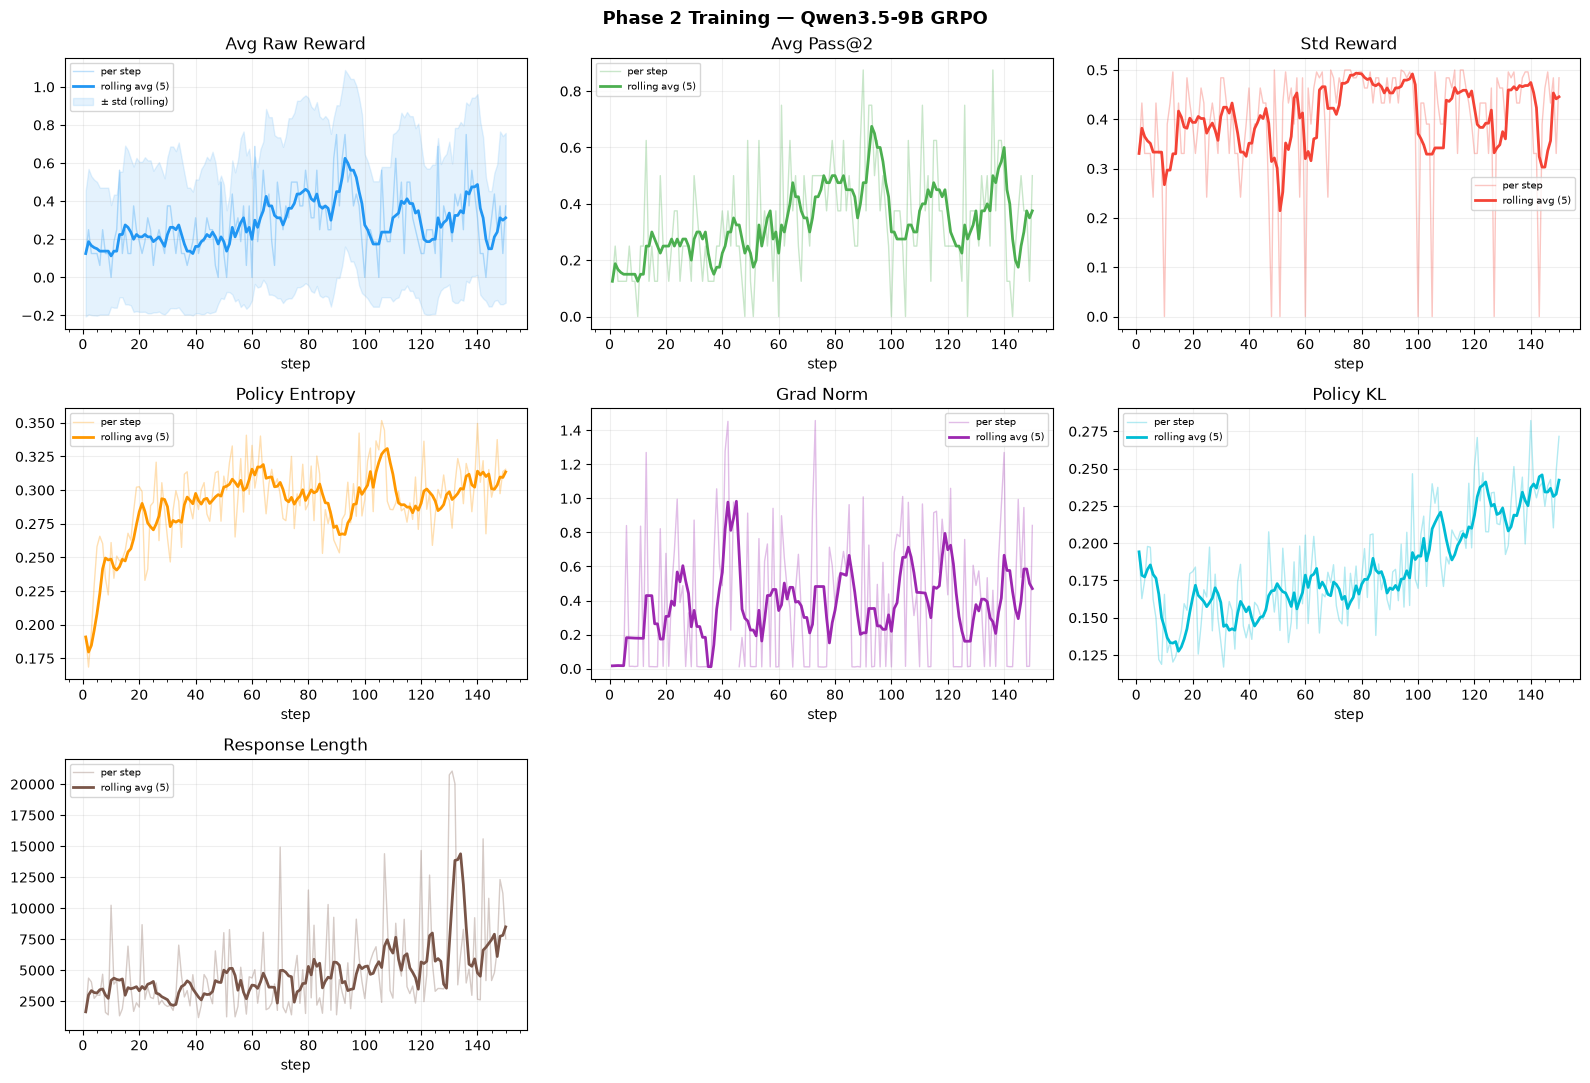

Saved: metrics/training_metrics_plot.png


In [62]:
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
fig.suptitle("Phase 2 Training — Qwen3.5-9B GRPO", fontsize=13, fontweight="bold")

def plot_panel(ax, y, title, color, std=None):
    r = rolling(y)
    ax.plot(steps, y, color=color, alpha=0.3, linewidth=1, label="per step")
    ax.plot(steps, r, color=color, linewidth=2, label="rolling avg (5)")
    if std is not None:
        r_std = rolling(std)
        r_arr = np.array([v if v is not None else np.nan for v in r])
        s_arr = np.array([v if v is not None else np.nan for v in r_std])
        ax.fill_between(steps, r_arr - s_arr, r_arr + s_arr, color=color, alpha=0.12, label="± std (rolling)")
    ax.set_title(title)
    ax.set_xlabel("step")
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=7)

plot_panel(axes[0,0], raw_reward,      "Avg Raw Reward",   "#2196F3", std=std_reward)
plot_panel(axes[0,1], pass2,           "Avg Pass@2",       "#4CAF50")
plot_panel(axes[0,2], std_reward,      "Std Reward",       "#F44336")
plot_panel(axes[1,0], entropy,         "Policy Entropy",   "#FF9800")
plot_panel(axes[1,1], grad_norm,       "Grad Norm",        "#9C27B0")
plot_panel(axes[1,2], policy_kl,       "Policy KL",        "#00BCD4")
plot_panel(axes[2,0], response_length, "Response Length",  "#795548")
axes[2,1].axis("off")
axes[2,2].axis("off")

plt.tight_layout()
plt.savefig("metrics/training_metrics_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: metrics/training_metrics_plot.png")

In [63]:
# Collapse Detection
# Collapse = policy stops exploring (entropy collapses) or always fails (std_reward=0 sustained)

ENTROPY_COLLAPSE_THRESHOLD = 0.05   # below this = collapsed
STD_COLLAPSE_THRESHOLD     = 0.05   # std_reward below this = all same reward
KL_DIVERGE_THRESHOLD       = 0.5    # above this = diverged from reference
GRAD_SPIKE_THRESHOLD       = 5.0    # above this = unstable update
SUSTAINED_ZERO_WINDOW      = 3      # N consecutive zero-std steps = collapse

flags = []

for i, m in enumerate(all_steps):
    s = m["step"]
    ent = m.get("policy_entropy", 1.0)
    std = m.get("std_reward", 1.0)
    kl  = m.get("policy_kl", 0.0)
    gn  = m.get("grad_norm", 0.0)
    if ent < ENTROPY_COLLAPSE_THRESHOLD:
        flags.append((s, "ENTROPY_COLLAPSE", f"entropy={ent:.4f}"))
    if kl > KL_DIVERGE_THRESHOLD:
        flags.append((s, "KL_DIVERGENCE",    f"kl={kl:.4f}"))
    if gn > GRAD_SPIKE_THRESHOLD:
        flags.append((s, "GRAD_SPIKE",       f"grad_norm={gn:.4f}"))

# Check for N consecutive steps with std_reward ~ 0
for i in range(len(all_steps) - SUSTAINED_ZERO_WINDOW + 1):
    window = all_steps[i:i+SUSTAINED_ZERO_WINDOW]
    if all(m.get("std_reward", 1.0) < STD_COLLAPSE_THRESHOLD for m in window):
        step_range = f"{window[0]['step']}–{window[-1]['step']}"
        flags.append((window[0]["step"], "SUSTAINED_ZERO_REWARD", f"steps {step_range}"))

print("=== Collapse Detection ===")
print(f"Thresholds: entropy<{ENTROPY_COLLAPSE_THRESHOLD}, std_reward<{STD_COLLAPSE_THRESHOLD} for {SUSTAINED_ZERO_WINDOW} consecutive steps, kl>{KL_DIVERGE_THRESHOLD}, grad_norm>{GRAD_SPIKE_THRESHOLD}")
print()

if flags:
    print(f"{'step':>5}  {'type':<25}  detail")
    for step, ftype, detail in sorted(flags):
        print(f"{step:>5}  {ftype:<25}  {detail}")
else:
    print("No collapse signals detected.")

print()
# Steps where std_reward < threshold
low_std_steps = [(m["step"], m.get("std_reward", 0)) for m in all_steps if m.get("std_reward", 1.0) < STD_COLLAPSE_THRESHOLD]
print(f"=== Steps with std_reward < {STD_COLLAPSE_THRESHOLD} ({len(low_std_steps)} total) ===")
if low_std_steps:
    print(f"{'step':>5}  {'std_reward':>10}")
    for s, v in low_std_steps:
        print(f"{s:>5}  {v:>10.4f}")
else:
    print("None")

print()
print("=== Per-step Summary (last 10) ===")
print(f"{'step':>5}  {'entropy':>8}  {'std_rwd':>8}  {'kl':>7}  {'grad_norm':>9}  status")
for m in all_steps[-10:]:
    ent = m.get("policy_entropy", 0)
    std = m.get("std_reward", 0)
    kl  = m.get("policy_kl", 0)
    gn  = m.get("grad_norm", 0)
    ok  = ent > ENTROPY_COLLAPSE_THRESHOLD and kl < KL_DIVERGE_THRESHOLD and gn < GRAD_SPIKE_THRESHOLD
    status = "✓ ok" if ok else "✗ FLAG"
    print(f"{m['step']:>5}  {ent:>8.3f}  {std:>8.4f}  {kl:>7.3f}  {gn:>9.3f}  {status}")

=== Collapse Detection ===
Thresholds: entropy<0.05, std_reward<0.05 for 3 consecutive steps, kl>0.5, grad_norm>5.0

No collapse signals detected.

=== Steps with std_reward < 0.05 (8 total) ===
 step  std_reward
   10      0.0000
   48      0.0000
   51      0.0000
   60      0.0000
  100      0.0000
  105      0.0000
  127      0.0000
  143      0.0000

=== Per-step Summary (last 10) ===
 step   entropy   std_rwd       kl  grad_norm  status
  141     0.306    0.3307    0.238      0.014  ✓ ok
  142     0.322    0.3307    0.230      0.012  ✓ ok
  143     0.268    0.0000    0.238      0.012  ✓ ok
  144     0.315    0.3903    0.240      0.438  ✓ ok
  145     0.295    0.4635    0.225      0.994  ✓ ok
  146     0.304    0.4961    0.238      0.536  ✓ ok
  147     0.338    0.4330    0.243      0.946  ✓ ok
  148     0.297    0.4841    0.210      0.013  ✓ ok
  149     0.314    0.3307    0.248      0.014  ✓ ok
  150     0.315    0.4841    0.272      0.841  ✓ ok


In [ ]:
from IPython.display import Markdown, display

METRICS = [
    ("avg_pass_at_2",          "avg_pass@2",     "{:.2f}"),
    ("std_reward",             "std_reward",     "{:.2f}"),
    ("policy_kl",              "policy_kl",      "{:.2f}"),
    ("policy_entropy",         "policy_entropy", "{:.2f}"),
    ("grad_norm",              "grad_norm",      "{:.2f}"),
    ("response_length",        "response_length","{:,.0f}"),
    ("num_error_trajectories", "num_errors",     "{:.2f}"),
    ("policy_loss",            "policy_loss",    "{:.3f}"),
]

PHASES = [(1, 50), (51, 100), (101, 150), (151, None)]

def phase_avg(key, lo, hi):
    vals = [m[key] for m in all_steps
            if lo <= m["step"] and (hi is None or m["step"] <= hi)
            and m.get(key) is not None]
    return np.mean(vals) if vals else float("nan")

last_step = all_steps[-1]["step"]
headers = ["Steps 1–50", "Steps 51–100", "Steps 101–150", f"Steps 151–{last_step}"]

rows = []
for key, label, fmt in METRICS:
    cells = []
    for lo, hi in PHASES:
        avg = phase_avg(key, lo, hi)
        cells.append(fmt.format(avg) if not np.isnan(avg) else "—")
    rows.append(f"| {label} | {' | '.join(cells)} |")

table = "\n".join([
    "| Metric | " + " | ".join(headers) + " |",
    "|--------|" + "|".join(["--------"] * len(headers)) + "|",
] + rows)

display(Markdown(table))

# Metric Insights

**avg_pass@2** — out of 8 tasks per step, how many the model solved on at least one of its 2 tries.
Pass rate almost doubled from the first phase (0.23) to the second phase (0.41). It dropped slightly in the third phase — most likely because those steps happened to sample harder tasks from the dataset. With only 8 tasks per step, a few hard draws in a row can pull the average down without the model actually getting worse. The recovery to 0.40 in the last phase confirms that — the dip was temporary.

**std_reward** — how mixed the results are each step — if all tasks fail or all pass, this is 0 and the model learns nothing.
Stayed above 0.37 across all phases and improved to 0.44 in the last phase. The model always had a mix of passes and fails each step, so it kept getting a learning signal. The zero-reward steps were all isolated — the model recovered every time.

**policy_kl** — how far the model has moved from where it started training.
Rose slowly through the first three phases (0.16 → 0.17 → 0.22), then jumped to 0.38 in the last phase. At steps 183 and 184 it crossed the 0.5 warning threshold. This is the first real flag in the run — the model is drifting more aggressively from its starting point. Worth watching closely in the next 10–20 steps to see if it stabilizes or keeps climbing.

**policy_entropy** — how varied the model's outputs are — low means it always does the same thing, high means it tries different approaches.
Stayed stable around 0.30 for the first three phases, then jumped sharply to 0.44 in the last phase — reaching as high as 0.70 at steps 183–184. This is connected to the KL spike. The model is suddenly exploring much more aggressively. Whether this is the model unlocking new strategies or becoming unstable is not yet clear.

**grad_norm** — how big each weight update is — very large updates mean the training is unstable.
Has been growing each phase: 0.34 → 0.36 → 0.46 → 0.64. Still well below the danger level of 5.0, but the trend is upward. Combined with the KL and entropy rises in the last phase, this suggests the model is making bigger and bigger updates.

**response_length** — total tokens the model generated across all tasks in a step.
Has nearly tripled from the first phase (3,531) to the last phase (10,003). The model is consistently using more turns and generating longer outputs as training progresses. This lines up with the model tackling harder tasks more thoroughly — but it also means each step is more expensive and the model may be hitting context limits on some tasks.

**num_errors** — how many of the 16 task attempts had a Docker or infrastructure failure rather than a real pass or fail result.
Fell from over 1 per step early on to near zero by the third phase. Slight uptick to 0.24 in the last phase — still low, but worth keeping an eye on.

**policy_loss** — how much the model's weights changed each step.
Stayed near zero across all phases. Slightly negative (-0.012) in the last phase, which is consistent with the model making more aggressive updates. No signs of instability.